# Assignment 4 – Tree & Graph Visualization

---

## Datasets

### Dataset 1 – Evolutionary Tree of Life (Phylogenetic Tree)
**Source:** Manually curated based on the Open Tree of Life project (https://tree.opentreeoflife.org/) and published phylogenetic literature.

**What nodes represent:** Each node is either a **species** (leaf node, e.g. *Homo sapiens*) or a **common ancestor / clade** (internal node, e.g. *Mammalia*, *Vertebrata*). 

**What edges represent:** Each directed edge from a parent node to a child node represents an **evolutionary (ancestral) relationship** — the child evolved/descended from the parent lineage.

**Why it's ideal for a tree:** Phylogenetic trees are by definition acyclic and hierarchical — every organism traces back to a single root (Last Universal Common Ancestor), with no cycles. This makes the data a perfect tree structure.

---

### Dataset 2 – Monarch Butterfly Migration Network
**Source:** Derived from Journey North citizen science data (https://journeynorth.org/monarchs) and USGS Monarch butterfly migration studies.

**What nodes represent:** Each node is a **geographic waypoint / region** that Monarch butterflies pass through during their annual multi-generational migration between Mexico and Canada (e.g. 'Michoacán Overwintering Site', 'Texas Gulf Coast', 'Great Lakes').

**What edges represent:** Each edge connects two regions with a recorded **migration corridor** — indicating that Monarch populations travel between those two waypoints. Edge weights represent the relative volume of butterfly movement observed.

**Why it's ideal for a graph:** Migration networks contain cycles (butterflies return south each autumn), multiple paths between nodes, and varying edge weights — making it a true weighted, undirected graph rather than a tree.

In [1]:
# ── Install dependencies if needed ──────────────────────────────────────────
# !pip install networkx matplotlib numpy

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from collections import defaultdict

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
print('Libraries loaded successfully.')

Libraries loaded successfully.


---
# Part 1 – Tree Dataset: Evolutionary Tree of Life
### Building the dataset

In [3]:
# ── Build the phylogenetic tree ──────────────────────────────────────────────
T = nx.DiGraph()

# Edges: (parent, child)  — ancestor → descendant
phylo_edges = [
    # Root splits
    ('Life (LUCA)', 'Bacteria'),
    ('Life (LUCA)', 'Archaea'),
    ('Life (LUCA)', 'Eukaryota'),

    # Bacteria
    ('Bacteria', 'Proteobacteria'),
    ('Bacteria', 'Firmicutes'),
    ('Bacteria', 'Cyanobacteria'),
    ('Proteobacteria', 'E. coli'),
    ('Proteobacteria', 'Salmonella'),
    ('Firmicutes', 'Bacillus subtilis'),
    ('Firmicutes', 'Staphylococcus aureus'),
    ('Cyanobacteria', 'Anabaena'),

    # Archaea
    ('Archaea', 'Methanobacteria'),
    ('Archaea', 'Thermococci'),
    ('Methanobacteria', 'Methanobacterium'),
    ('Thermococci', 'Thermococcus'),

    # Eukaryota
    ('Eukaryota', 'Fungi'),
    ('Eukaryota', 'Plantae'),
    ('Eukaryota', 'Animalia'),
    ('Eukaryota', 'Protista'),

    # Fungi
    ('Fungi', 'Ascomycota'),
    ('Fungi', 'Basidiomycota'),
    ('Ascomycota', 'Saccharomyces cerevisiae'),
    ('Ascomycota', 'Penicillium'),
    ('Basidiomycota', 'Amanita muscaria'),
    ('Basidiomycota', 'Porcini mushroom'),

    # Plantae
    ('Plantae', 'Bryophyta'),
    ('Plantae', 'Tracheophyta'),
    ('Bryophyta', 'Marchantia (liverwort)'),
    ('Tracheophyta', 'Gymnospermae'),
    ('Tracheophyta', 'Angiospermae'),
    ('Gymnospermae', 'Pinus (pine)'),
    ('Gymnospermae', 'Ginkgo biloba'),
    ('Angiospermae', 'Rosa (rose)'),
    ('Angiospermae', 'Zea mays (maize)'),
    ('Angiospermae', 'Arabidopsis thaliana'),

    # Animalia
    ('Animalia', 'Arthropoda'),
    ('Animalia', 'Chordata'),
    ('Animalia', 'Mollusca'),
    ('Arthropoda', 'Insecta'),
    ('Arthropoda', 'Arachnida'),
    ('Insecta', 'Lepidoptera'),
    ('Insecta', 'Coleoptera'),
    ('Lepidoptera', 'Danaus plexippus (Monarch)'),
    ('Lepidoptera', 'Papilio machaon (Swallowtail)'),
    ('Coleoptera', 'Coccinella septempunctata (Ladybug)'),
    ('Arachnida', 'Latrodectus (Black Widow)'),
    ('Arachnida', 'Scorpiones'),
    ('Chordata', 'Actinopterygii (Ray-fin fish)'),
    ('Chordata', 'Amphibia'),
    ('Chordata', 'Reptilia'),
    ('Chordata', 'Aves'),
    ('Chordata', 'Mammalia'),
    ('Amphibia', 'Rana (frog)'),
    ('Reptilia', 'Crocodilia'),
    ('Reptilia', 'Squamata'),
    ('Squamata', 'Python regius'),
    ('Squamata', 'Iguana iguana'),
    ('Aves', 'Struthioniformes'),
    ('Aves', 'Passeriformes'),
    ('Struthioniformes', 'Struthio camelus (Ostrich)'),
    ('Passeriformes', 'Corvus (Crow)'),
    ('Mammalia', 'Chiroptera'),
    ('Mammalia', 'Cetacea'),
    ('Mammalia', 'Primates'),
    ('Chiroptera', 'Pteropus (Flying fox)'),
    ('Cetacea', 'Balaenoptera musculus (Blue whale)'),
    ('Cetacea', 'Delphinus delphis (Dolphin)'),
    ('Primates', 'Pan troglodytes (Chimpanzee)'),
    ('Primates', 'Homo sapiens'),
    ('Primates', 'Gorilla gorilla'),

    # Protista
    ('Protista', 'Amoeba proteus'),
    ('Protista', 'Plasmodium (Malaria parasite)'),
]

T.add_edges_from(phylo_edges)

# Node metadata for coloring
domain_colors = {
    'Bacteria': '#e07b54',
    'Archaea': '#c084fc',
    'Fungi': '#fbbf24',
    'Plantae': '#4ade80',
    'Animalia': '#38bdf8',
    'Protista': '#f472b6',
    'Root': '#f8fafc',
}

def get_domain(node):
    bact = {n for n, _ in nx.bfs_edges(T, 'Bacteria')} | {'Bacteria'}
    arch = {n for n, _ in nx.bfs_edges(T, 'Archaea')} | {'Archaea'}
    fungi = {n for n, _ in nx.bfs_edges(T, 'Fungi')} | {'Fungi'}
    plant = {n for n, _ in nx.bfs_edges(T, 'Plantae')} | {'Plantae'}
    animal = {n for n, _ in nx.bfs_edges(T, 'Animalia')} | {'Animalia'}
    protist = {n for n, _ in nx.bfs_edges(T, 'Protista')} | {'Protista'}
    if node in bact: return 'Bacteria'
    if node in arch: return 'Archaea'
    if node in fungi: return 'Fungi'
    if node in plant: return 'Plantae'
    if node in animal: return 'Animalia'
    if node in protist: return 'Protista'
    return 'Root'

print(f'Tree built: {T.number_of_nodes()} nodes, {T.number_of_edges()} edges')
print(f'Is a tree (DAG + single root): {nx.is_tree(T)}')

Tree built: 73 nodes, 72 edges
Is a tree (DAG + single root): True


---
### Tree Layout 1 – Radial (Dendrogram) Layout
A circular layout emanating from the root — mimics how biologists traditionally draw phylogenies.

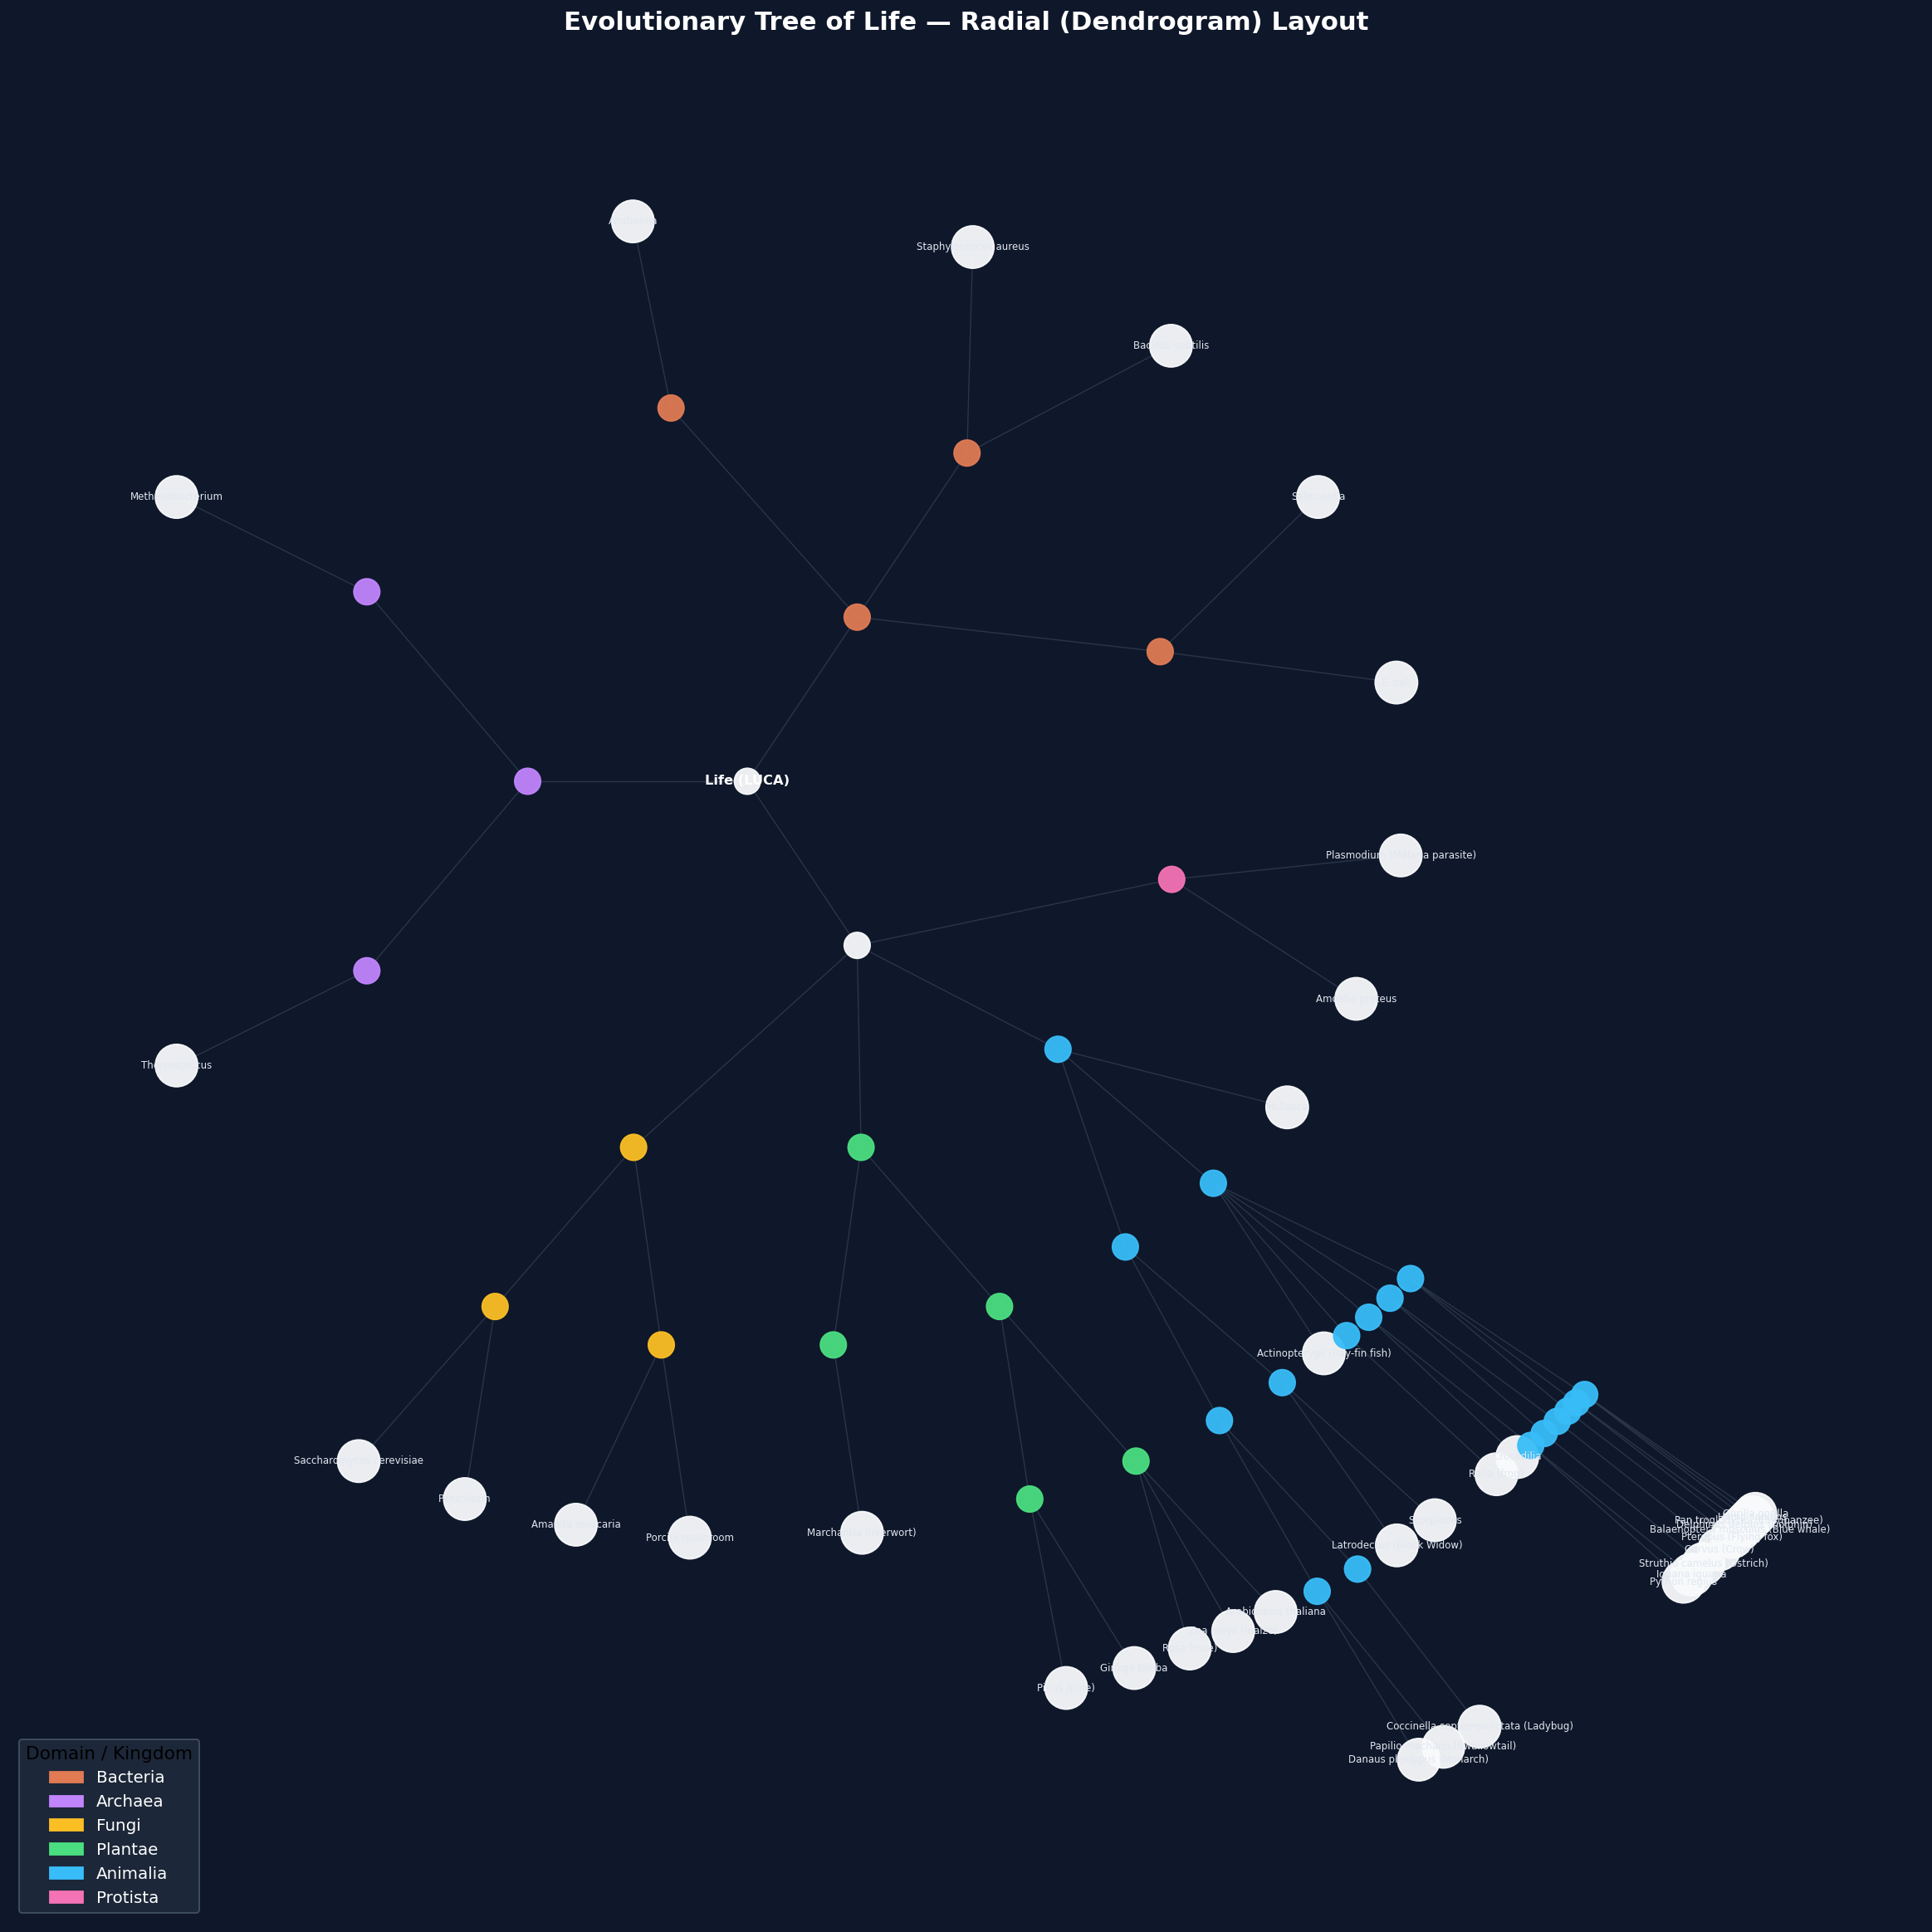

Saved: tree_radial.png


In [4]:
def radial_tree_layout(G, root):
    """Compute a radial layout by doing BFS and distributing angles."""
    pos = {}
    # BFS to get levels
    levels = defaultdict(list)
    for node, depth in nx.bfs_successors(G, root):
        pass
    bfs_order = list(nx.bfs_tree(G, root).nodes())
    
    def place(node, angle_start, angle_end, depth):
        r = depth
        mid_angle = (angle_start + angle_end) / 2
        pos[node] = (r * np.cos(mid_angle), r * np.sin(mid_angle))
        children = list(G.successors(node))
        if not children:
            return
        span = angle_end - angle_start
        sub = span / len(children)
        for i, child in enumerate(children):
            place(child, angle_start + i * sub, angle_start + (i+1) * sub, depth + 1)
    
    place(root, 0, 2 * np.pi, 0)
    return pos

# ── Figure ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 18), facecolor='#0f172a')
ax.set_facecolor('#0f172a')
ax.axis('off')

root = 'Life (LUCA)'
pos = radial_tree_layout(T, root)

node_colors = [domain_colors[get_domain(n)] for n in T.nodes()]
node_sizes  = [800 if T.out_degree(n) == 0 else 300 for n in T.nodes()]

# Draw edges first
nx.draw_networkx_edges(
    T, pos, ax=ax,
    edge_color='#334155', width=0.8, arrows=False, alpha=0.7
)

# Draw nodes
nx.draw_networkx_nodes(
    T, pos, ax=ax,
    node_color=node_colors,
    node_size=node_sizes,
    alpha=0.95
)

# Labels only for leaf nodes (species)
leaf_labels = {n: n for n in T.nodes() if T.out_degree(n) == 0}
nx.draw_networkx_labels(
    T, pos, labels=leaf_labels, ax=ax,
    font_size=6.5, font_color='#e2e8f0', font_family='DejaVu Sans'
)

# Root label
nx.draw_networkx_labels(
    T, pos, labels={root: root}, ax=ax,
    font_size=9, font_color='white', font_weight='bold'
)

# Legend
legend_handles = [mpatches.Patch(color=c, label=d) for d, c in domain_colors.items() if d != 'Root']
ax.legend(handles=legend_handles, loc='lower left', fontsize=11,
          facecolor='#1e293b', edgecolor='#475569', labelcolor='white',
          framealpha=0.9, title='Domain / Kingdom', title_fontsize=12)

ax.set_title('Evolutionary Tree of Life — Radial (Dendrogram) Layout',
             fontsize=17, color='white', pad=20, fontweight='bold')

plt.tight_layout()
plt.savefig('tree_radial.png', dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()
print('Saved: tree_radial.png')

---
### Tree Layout 2 – Hierarchical (Top-Down) Layout
Classic top-down tree — root at top, leaves at bottom. Great for showing depth and branching structure.

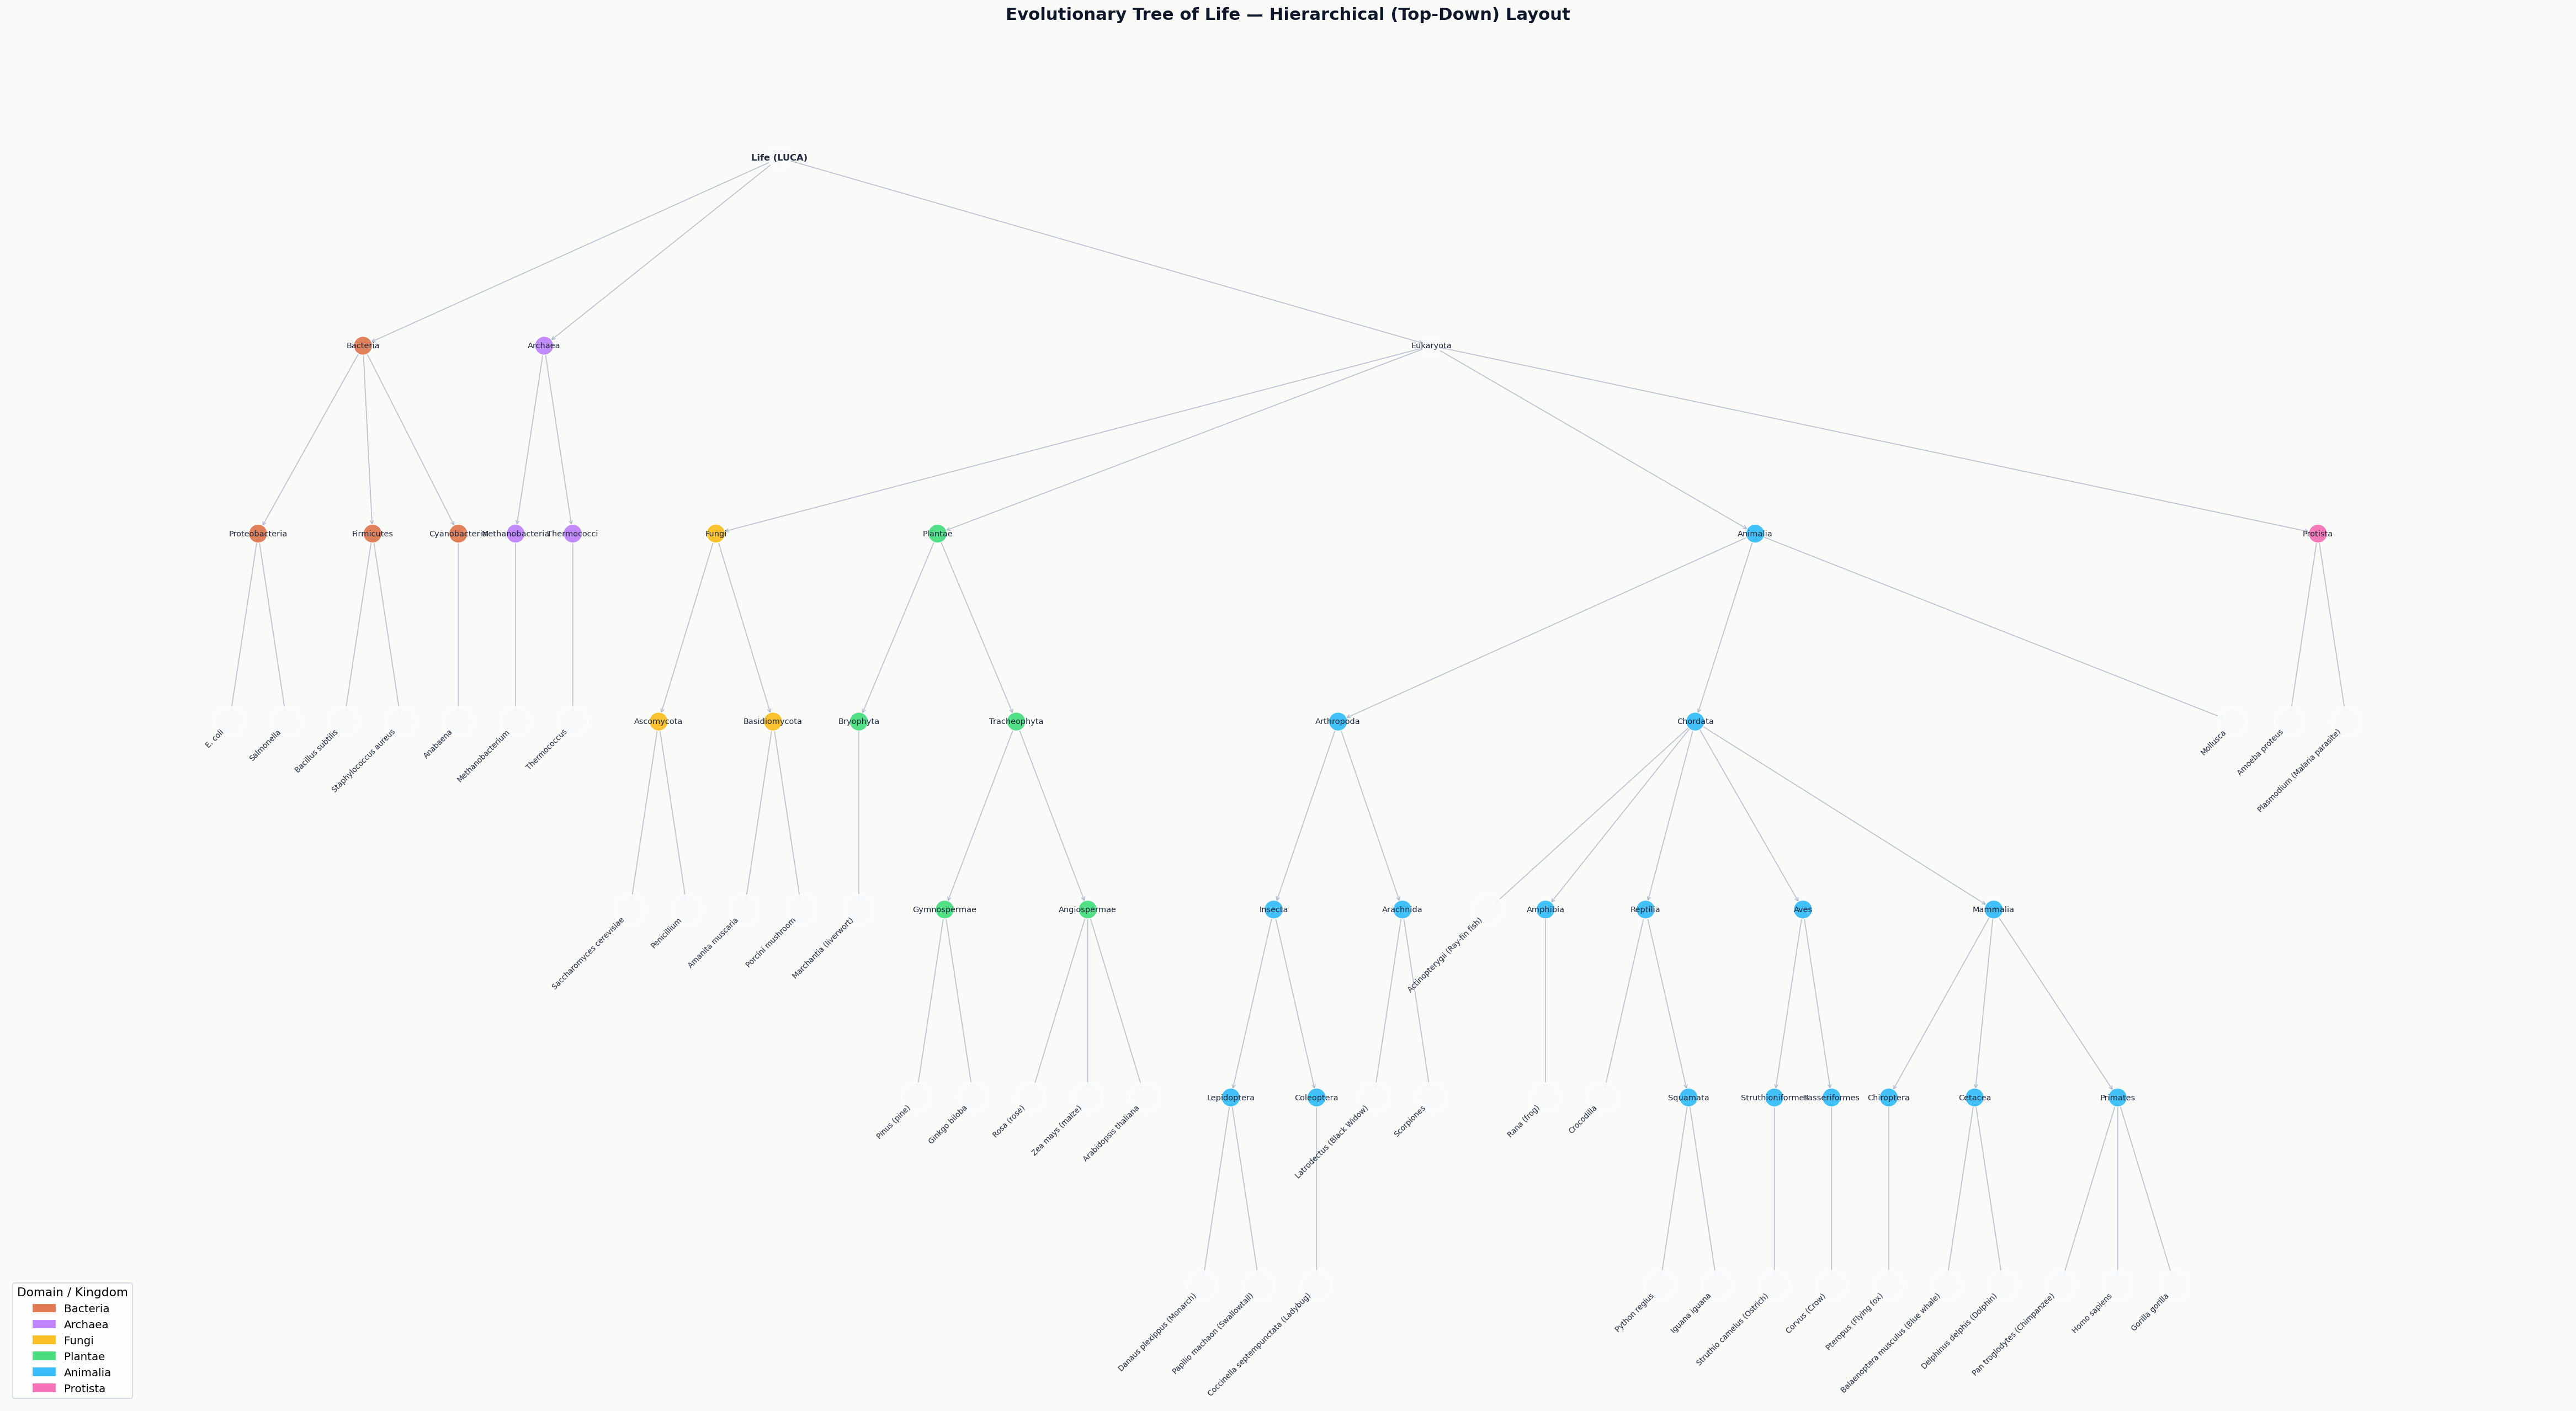

Saved: tree_hierarchical.png


In [5]:
def count_leaves(G, node):
    """Count the number of leaf descendants of a node."""
    children = list(G.successors(node))
    if not children:
        return 1
    return sum(count_leaves(G, c) for c in children)

def hierarchy_pos_leafspaced(G, root, x_gap=1.0, y_gap=1.0):
    """
    Leaf-count-proportional hierarchical layout.
    Each node's x-position is the centroid of its leaf descendants.
    This prevents crowding in deep/wide subtrees.
    """
    pos = {}
    leaf_x = [0]  # mutable counter for leaf x positions

    def assign_x(node, depth):
        children = list(G.successors(node))
        if not children:
            x = leaf_x[0] * x_gap
            leaf_x[0] += 1
            pos[node] = (x, -depth * y_gap)
        else:
            for child in children:
                assign_x(child, depth + 1)
            child_xs = [pos[c][0] for c in children]
            pos[node] = (sum(child_xs) / len(child_xs), -depth * y_gap)

    assign_x(root, 0)
    return pos

# ── Figure ──────────────────────────────────────────────────────────────────
# Use large figure; x_gap controls horizontal spread per leaf
pos_h = hierarchy_pos_leafspaced(T, root, x_gap=0.55, y_gap=1.8)

# Compute figure width proportional to number of leaves
n_leaves = sum(1 for n in T.nodes() if T.out_degree(n) == 0)
fig_w = max(36, n_leaves * 0.55)
fig_h = 20

fig, ax = plt.subplots(figsize=(fig_w, fig_h), facecolor='#fafaf9')
ax.set_facecolor('#fafaf9')
ax.axis('off')

node_colors_h = [domain_colors[get_domain(n)] for n in T.nodes()]
node_sizes_h  = [900 if T.out_degree(n) == 0 else 500 if T.in_degree(n) == 0 else 350 for n in T.nodes()]

nx.draw_networkx_edges(
    T, pos_h, ax=ax,
    edge_color='#94a3b8', width=1.0, arrows=True,
    arrowstyle='->', arrowsize=8, alpha=0.6
)

nx.draw_networkx_nodes(
    T, pos_h, ax=ax,
    node_color=node_colors_h,
    node_size=node_sizes_h,
    edgecolors='white', linewidths=0.8,
    alpha=0.95
)

# Labels: rotate leaf labels for readability
for node, (x, y) in pos_h.items():
    is_leaf = T.out_degree(node) == 0
    is_root = T.in_degree(node) == 0
    fontsize = 7.5 if is_leaf else 9 if is_root else 8
    fontweight = 'bold' if is_root else 'normal'
    rotation = 45 if is_leaf else 0
    ha = 'right' if is_leaf else 'center'
    va = 'top' if is_leaf else 'center'
    offset = (-4, -6) if is_leaf else (0, 0)
    ax.annotate(node, (x, y), fontsize=fontsize, color='#1e293b',
                fontweight=fontweight, rotation=rotation,
                ha=ha, va=va,
                xytext=offset, textcoords='offset points')

legend_handles = [mpatches.Patch(color=c, label=d) for d, c in domain_colors.items() if d != 'Root']
ax.legend(handles=legend_handles, loc='lower left', fontsize=11,
          facecolor='white', edgecolor='#cbd5e1', framealpha=0.9,
          title='Domain / Kingdom', title_fontsize=12)

ax.set_title('Evolutionary Tree of Life — Hierarchical (Top-Down) Layout',
             fontsize=17, color='#0f172a', pad=20, fontweight='bold')

plt.tight_layout()
plt.savefig('tree_hierarchical.png', dpi=150, bbox_inches='tight', facecolor='#fafaf9')
plt.show()
print('Saved: tree_hierarchical.png')

---
# Part 2 – Graph Dataset: Monarch Butterfly Migration Network
### Building the dataset

In [6]:
# ── Monarch Butterfly Migration Graph ────────────────────────────────────────
G = nx.Graph()

# Nodes: waypoint regions with approximate lat/lon for geographic positioning
waypoints = {
    'Michoacán\n(Overwinter)':      (19.5, -100.1),
    'Jalisco\nHighlands':           (20.7,  -103.4),
    'Texas\nGulf Coast':            (28.0,  -97.0),
    'Central Texas':                (30.3,  -97.7),
    'Oklahoma\nPrairies':           (35.5,  -97.5),
    'Kansas\nGrasslands':           (38.5,  -98.3),
    'Nebraska\nRiver Valleys':      (41.5,  -99.9),
    'Iowa\nCorn Belt':              (41.9,  -93.6),
    'Illinois\nPrairie':            (40.6,  -89.4),
    'Michigan\nGreat Lakes':        (44.3,  -85.6),
    'Ohio\nWetlands':               (40.5,  -82.5),
    'Ontario\nMilkweed Fields':     (44.0,  -80.0),
    'Minnesota\nNorthwoods':        (46.4,  -94.3),
    'Wisconsin\nDairyland':         (44.5,  -89.5),
    'New York\nHudson Valley':      (42.1,  -74.0),
    'New England\nCoast':           (42.5,  -71.5),
    'Atlantic\nFlyway Coast':       (37.5,  -76.0),
    'Mississippi\nBottomlands':     (34.0,  -90.5),
    'Arkansas\nOzarks':             (35.3,  -92.0),
    'Louisiana\nMarshes':           (29.5,  -91.2),
    'Florida\nPanhandle':           (30.5,  -86.2),
}

G.add_nodes_from(waypoints.keys())

# Edges: (node_a, node_b, weight)  —  weight = relative migration volume (1-10)
migration_edges = [
    # Spring northward migration
    ('Michoacán\n(Overwinter)', 'Texas\nGulf Coast', 10),
    ('Michoacán\n(Overwinter)', 'Jalisco\nHighlands', 4),
    ('Jalisco\nHighlands', 'Central Texas', 3),
    ('Texas\nGulf Coast', 'Central Texas', 8),
    ('Texas\nGulf Coast', 'Louisiana\nMarshes', 5),
    ('Louisiana\nMarshes', 'Mississippi\nBottomlands', 4),
    ('Mississippi\nBottomlands', 'Arkansas\nOzarks', 4),
    ('Arkansas\nOzarks', 'Illinois\nPrairie', 4),
    ('Central Texas', 'Oklahoma\nPrairies', 9),
    ('Oklahoma\nPrairies', 'Kansas\nGrasslands', 8),
    ('Kansas\nGrasslands', 'Nebraska\nRiver Valleys', 7),
    ('Kansas\nGrasslands', 'Iowa\nCorn Belt', 6),
    ('Nebraska\nRiver Valleys', 'Minnesota\nNorthwoods', 5),
    ('Iowa\nCorn Belt', 'Wisconsin\nDairyland', 5),
    ('Iowa\nCorn Belt', 'Illinois\nPrairie', 6),
    ('Wisconsin\nDairyland', 'Michigan\nGreat Lakes', 6),
    ('Illinois\nPrairie', 'Michigan\nGreat Lakes', 7),
    ('Michigan\nGreat Lakes', 'Ontario\nMilkweed Fields', 8),
    ('Minnesota\nNorthwoods', 'Ontario\nMilkweed Fields', 4),
    # Eastern corridor
    ('Ohio\nWetlands', 'Michigan\nGreat Lakes', 5),
    ('Ohio\nWetlands', 'Ontario\nMilkweed Fields', 6),
    ('Ohio\nWetlands', 'New York\nHudson Valley', 4),
    ('New York\nHudson Valley', 'New England\nCoast', 3),
    ('New York\nHudson Valley', 'Ontario\nMilkweed Fields', 3),
    # Atlantic flyway (fall southward)
    ('New England\nCoast', 'Atlantic\nFlyway Coast', 5),
    ('Atlantic\nFlyway Coast', 'Florida\nPanhandle', 4),
    ('Florida\nPanhandle', 'Louisiana\nMarshes', 3),
    # Cross connections
    ('Arkansas\nOzarks', 'Mississippi\nBottomlands', 3),
    ('Wisconsin\nDairyland', 'Minnesota\nNorthwoods', 3),
    ('Illinois\nPrairie', 'Ohio\nWetlands', 5),
]

for u, v, w in migration_edges:
    G.add_edge(u, v, weight=w)

# Node categories for coloring
node_type = {}
for n in G.nodes():
    if 'Overwinter' in n: node_type[n] = 'Overwintering Site'
    elif n in ['Texas\nGulf Coast', 'Ontario\nMilkweed Fields']: node_type[n] = 'Key Breeding Hub'
    else: node_type[n] = 'Migration Waypoint'

type_colors = {
    'Overwintering Site': '#f97316',
    'Key Breeding Hub': '#facc15',
    'Migration Waypoint': '#60a5fa',
}

print(f'Graph built: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')
print(f'Is connected: {nx.is_connected(G)}')
print(f'Avg degree: {np.mean([d for _, d in G.degree()]):.2f}')

Graph built: 21 nodes, 29 edges
Is connected: True
Avg degree: 2.76


---
### Graph Layout 1 – Geographic (Lat/Lon) Layout
Positions nodes at their real geographic coordinates. Lets you see the actual migration corridors over North America.

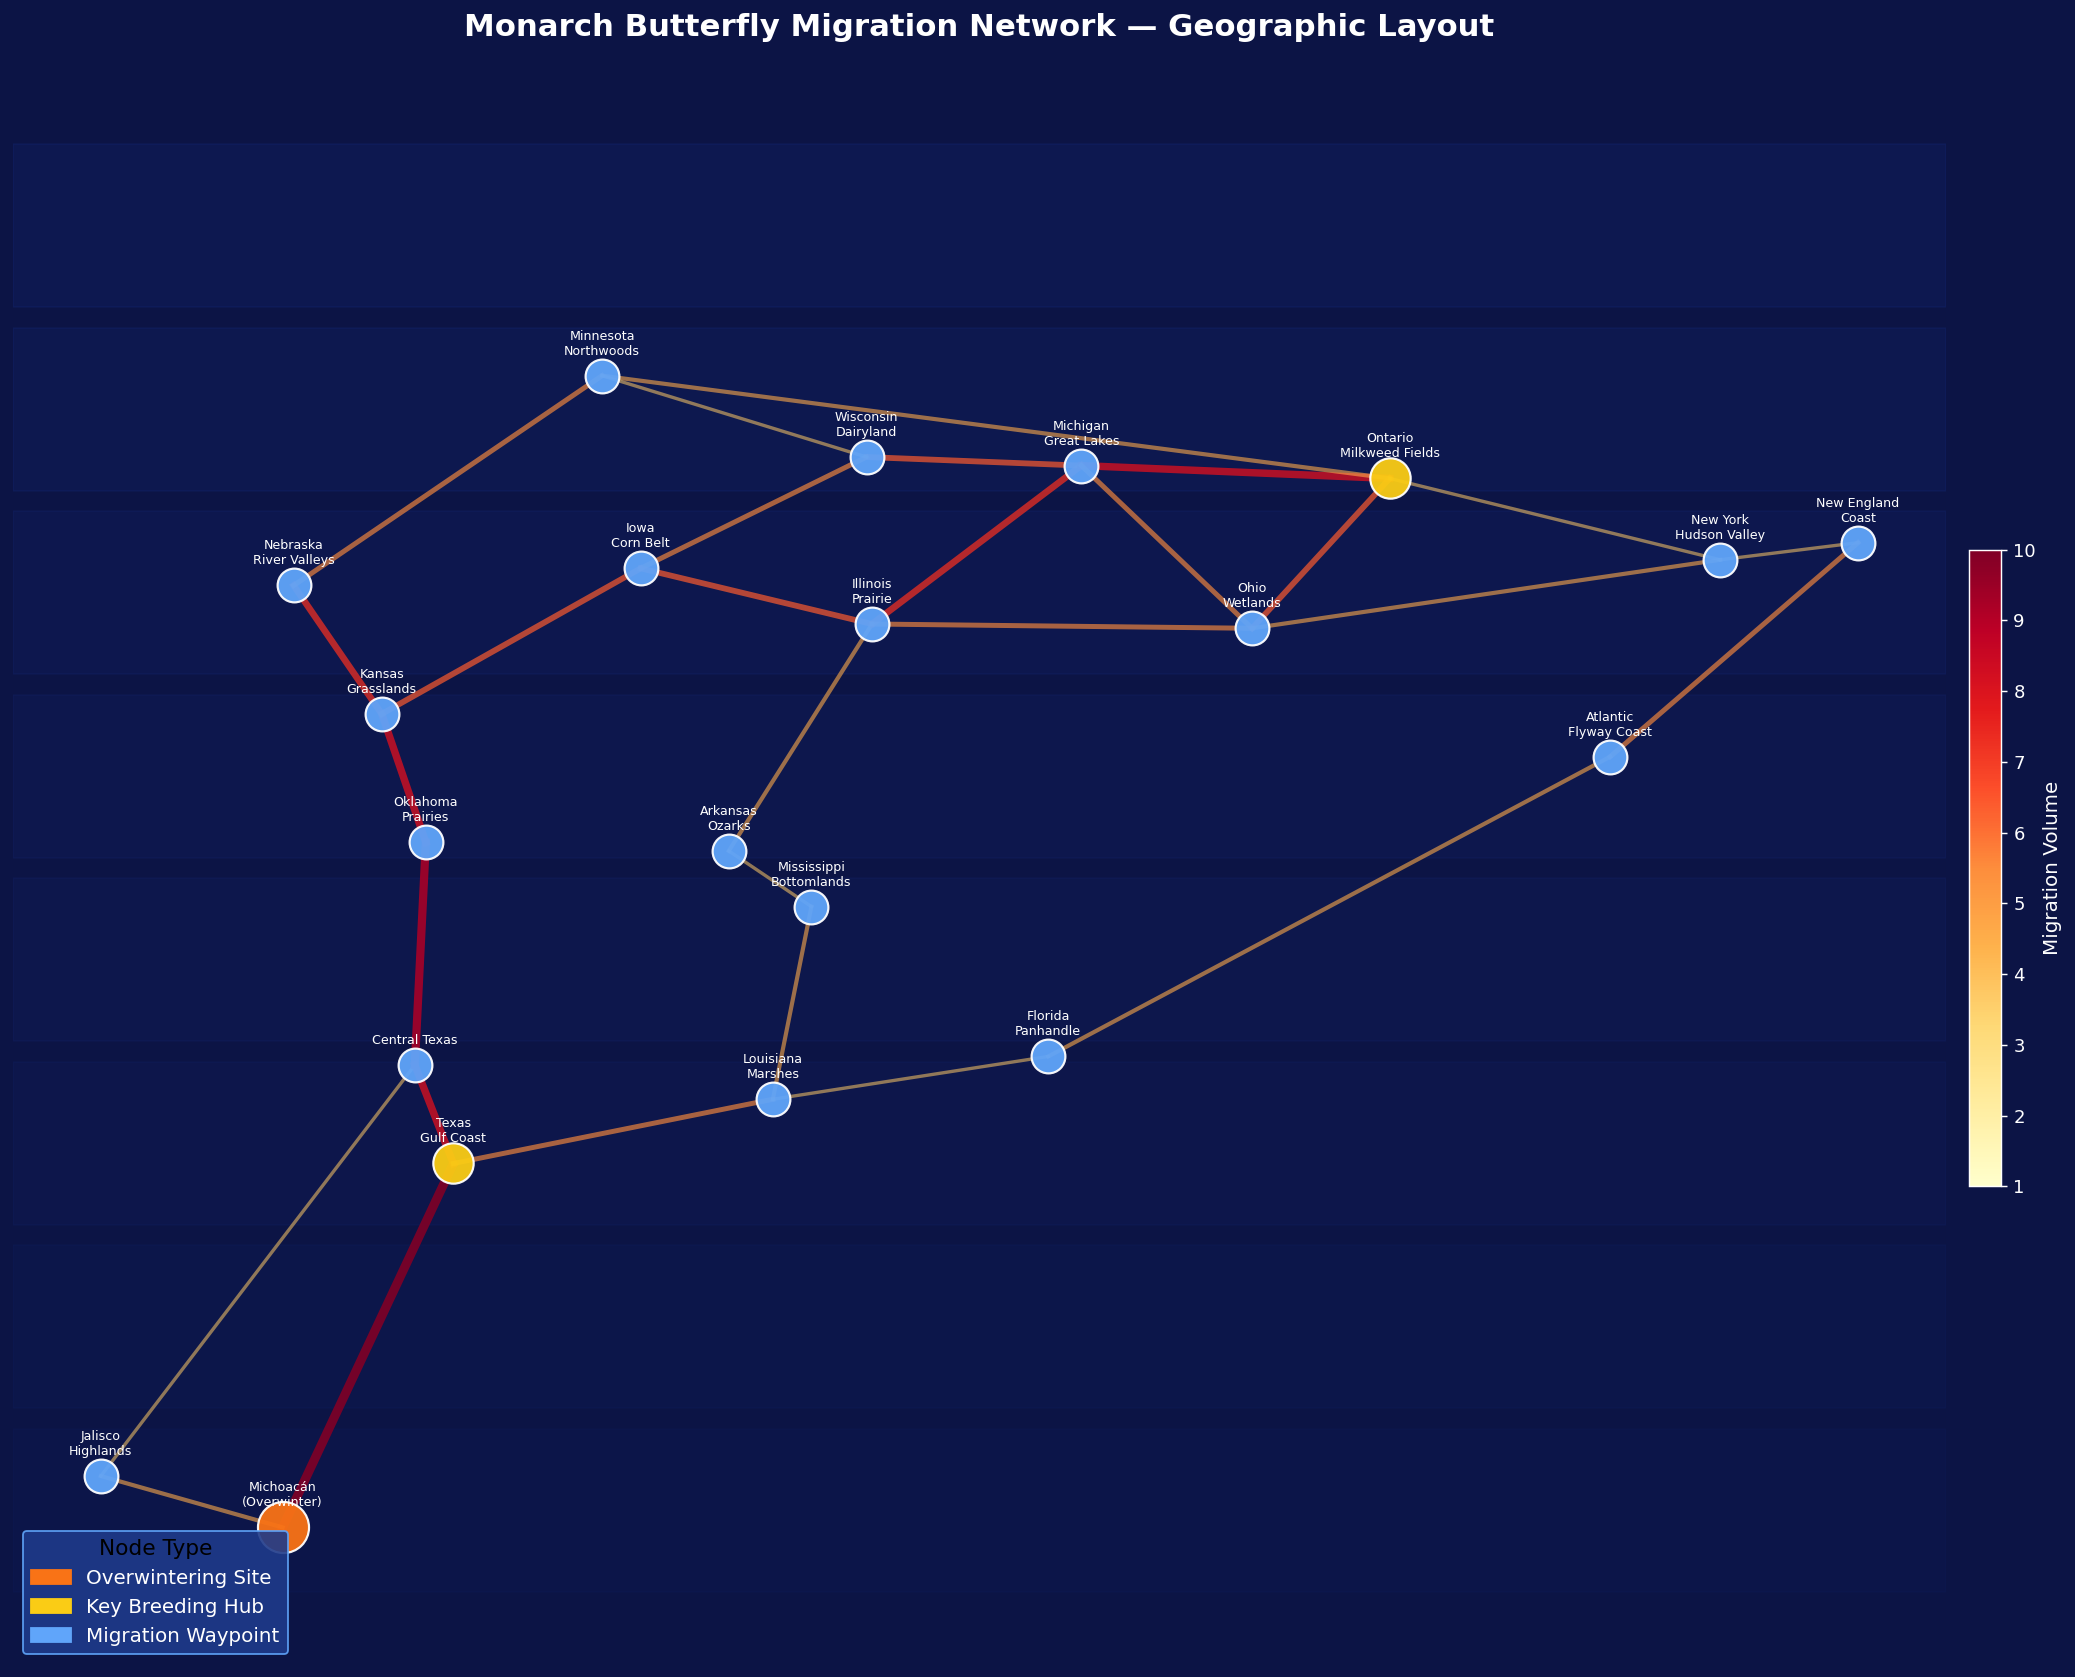

Saved: graph_geographic.png


In [7]:
# ── Geographic layout using lon/lat ─────────────────────────────────────────
geo_pos = {n: (waypoints[n][1], waypoints[n][0]) for n in G.nodes()}  # (lon, lat)

weights = [G[u][v]['weight'] for u, v in G.edges()]
max_w = max(weights)

fig, ax = plt.subplots(figsize=(18, 13), facecolor='#0c1445')
ax.set_facecolor('#0c1445')
ax.axis('off')

# Draw gradient background bands (simulate latitude bands)
for i, lat in enumerate(np.linspace(18, 48, 8)):
    alpha = 0.04 + 0.01 * i
    ax.axhspan(lat, lat + 3.8, color='#1e40af', alpha=alpha)

# Edge thickness and color by weight
edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
for (u, v), w in zip(G.edges(), edge_weights):
    x = [geo_pos[u][0], geo_pos[v][0]]
    y = [geo_pos[u][1], geo_pos[v][1]]
    alpha = 0.4 + 0.05 * w
    lw = 0.5 + w * 0.45
    # Color edges by weight: low=blue, high=orange
    color = plt.cm.YlOrRd(w / max_w)
    ax.plot(x, y, color=color, linewidth=lw, alpha=alpha, zorder=1)

# Draw nodes
nc = [type_colors[node_type[n]] for n in G.nodes()]
ns = [800 if node_type[n] == 'Overwintering Site' else
      500 if node_type[n] == 'Key Breeding Hub' else 350 for n in G.nodes()]

for n, (x, y) in geo_pos.items():
    col = type_colors[node_type[n]]
    size = 800 if node_type[n] == 'Overwintering Site' else 500 if node_type[n] == 'Key Breeding Hub' else 350
    ax.scatter(x, y, s=size, c=col, zorder=3, edgecolors='white', linewidths=1.2, alpha=0.95)
    # Labels
    ax.annotate(n, (x, y), fontsize=7, color='white', ha='center', va='bottom',
                xytext=(0, 10), textcoords='offset points',
                fontfamily='DejaVu Sans')

# Colorbar for edge weight
sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=plt.Normalize(1, max_w))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.4, pad=0.01)
cbar.set_label('Migration Volume', color='white', fontsize=11)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')
cbar.outline.set_edgecolor('white')

# Legend
legend_handles = [mpatches.Patch(color=c, label=t) for t, c in type_colors.items()]
ax.legend(handles=legend_handles, loc='lower left', fontsize=11,
          facecolor='#1e3a8a', edgecolor='#60a5fa', labelcolor='white',
          framealpha=0.9, title='Node Type', title_fontsize=12)

# North arrow
ax.annotate('N↑', xy=(-108, 46), fontsize=14, color='white', fontweight='bold')

ax.set_title('Monarch Butterfly Migration Network — Geographic Layout',
             fontsize=17, color='white', pad=20, fontweight='bold')
ax.set_xlabel('Longitude', color='white', fontsize=11)
ax.set_ylabel('Latitude', color='white', fontsize=11)
ax.tick_params(colors='white')
for sp in ax.spines.values(): sp.set_edgecolor('#334155')

plt.tight_layout()
plt.savefig('graph_geographic.png', dpi=150, bbox_inches='tight', facecolor='#0c1445')
plt.show()
print('Saved: graph_geographic.png')

---
### Graph Layout 2 – Force-Directed (Spring) Layout
Nodes are pushed apart and pulled together by edge weights. Highly connected nodes cluster together — reveals migration hubs.

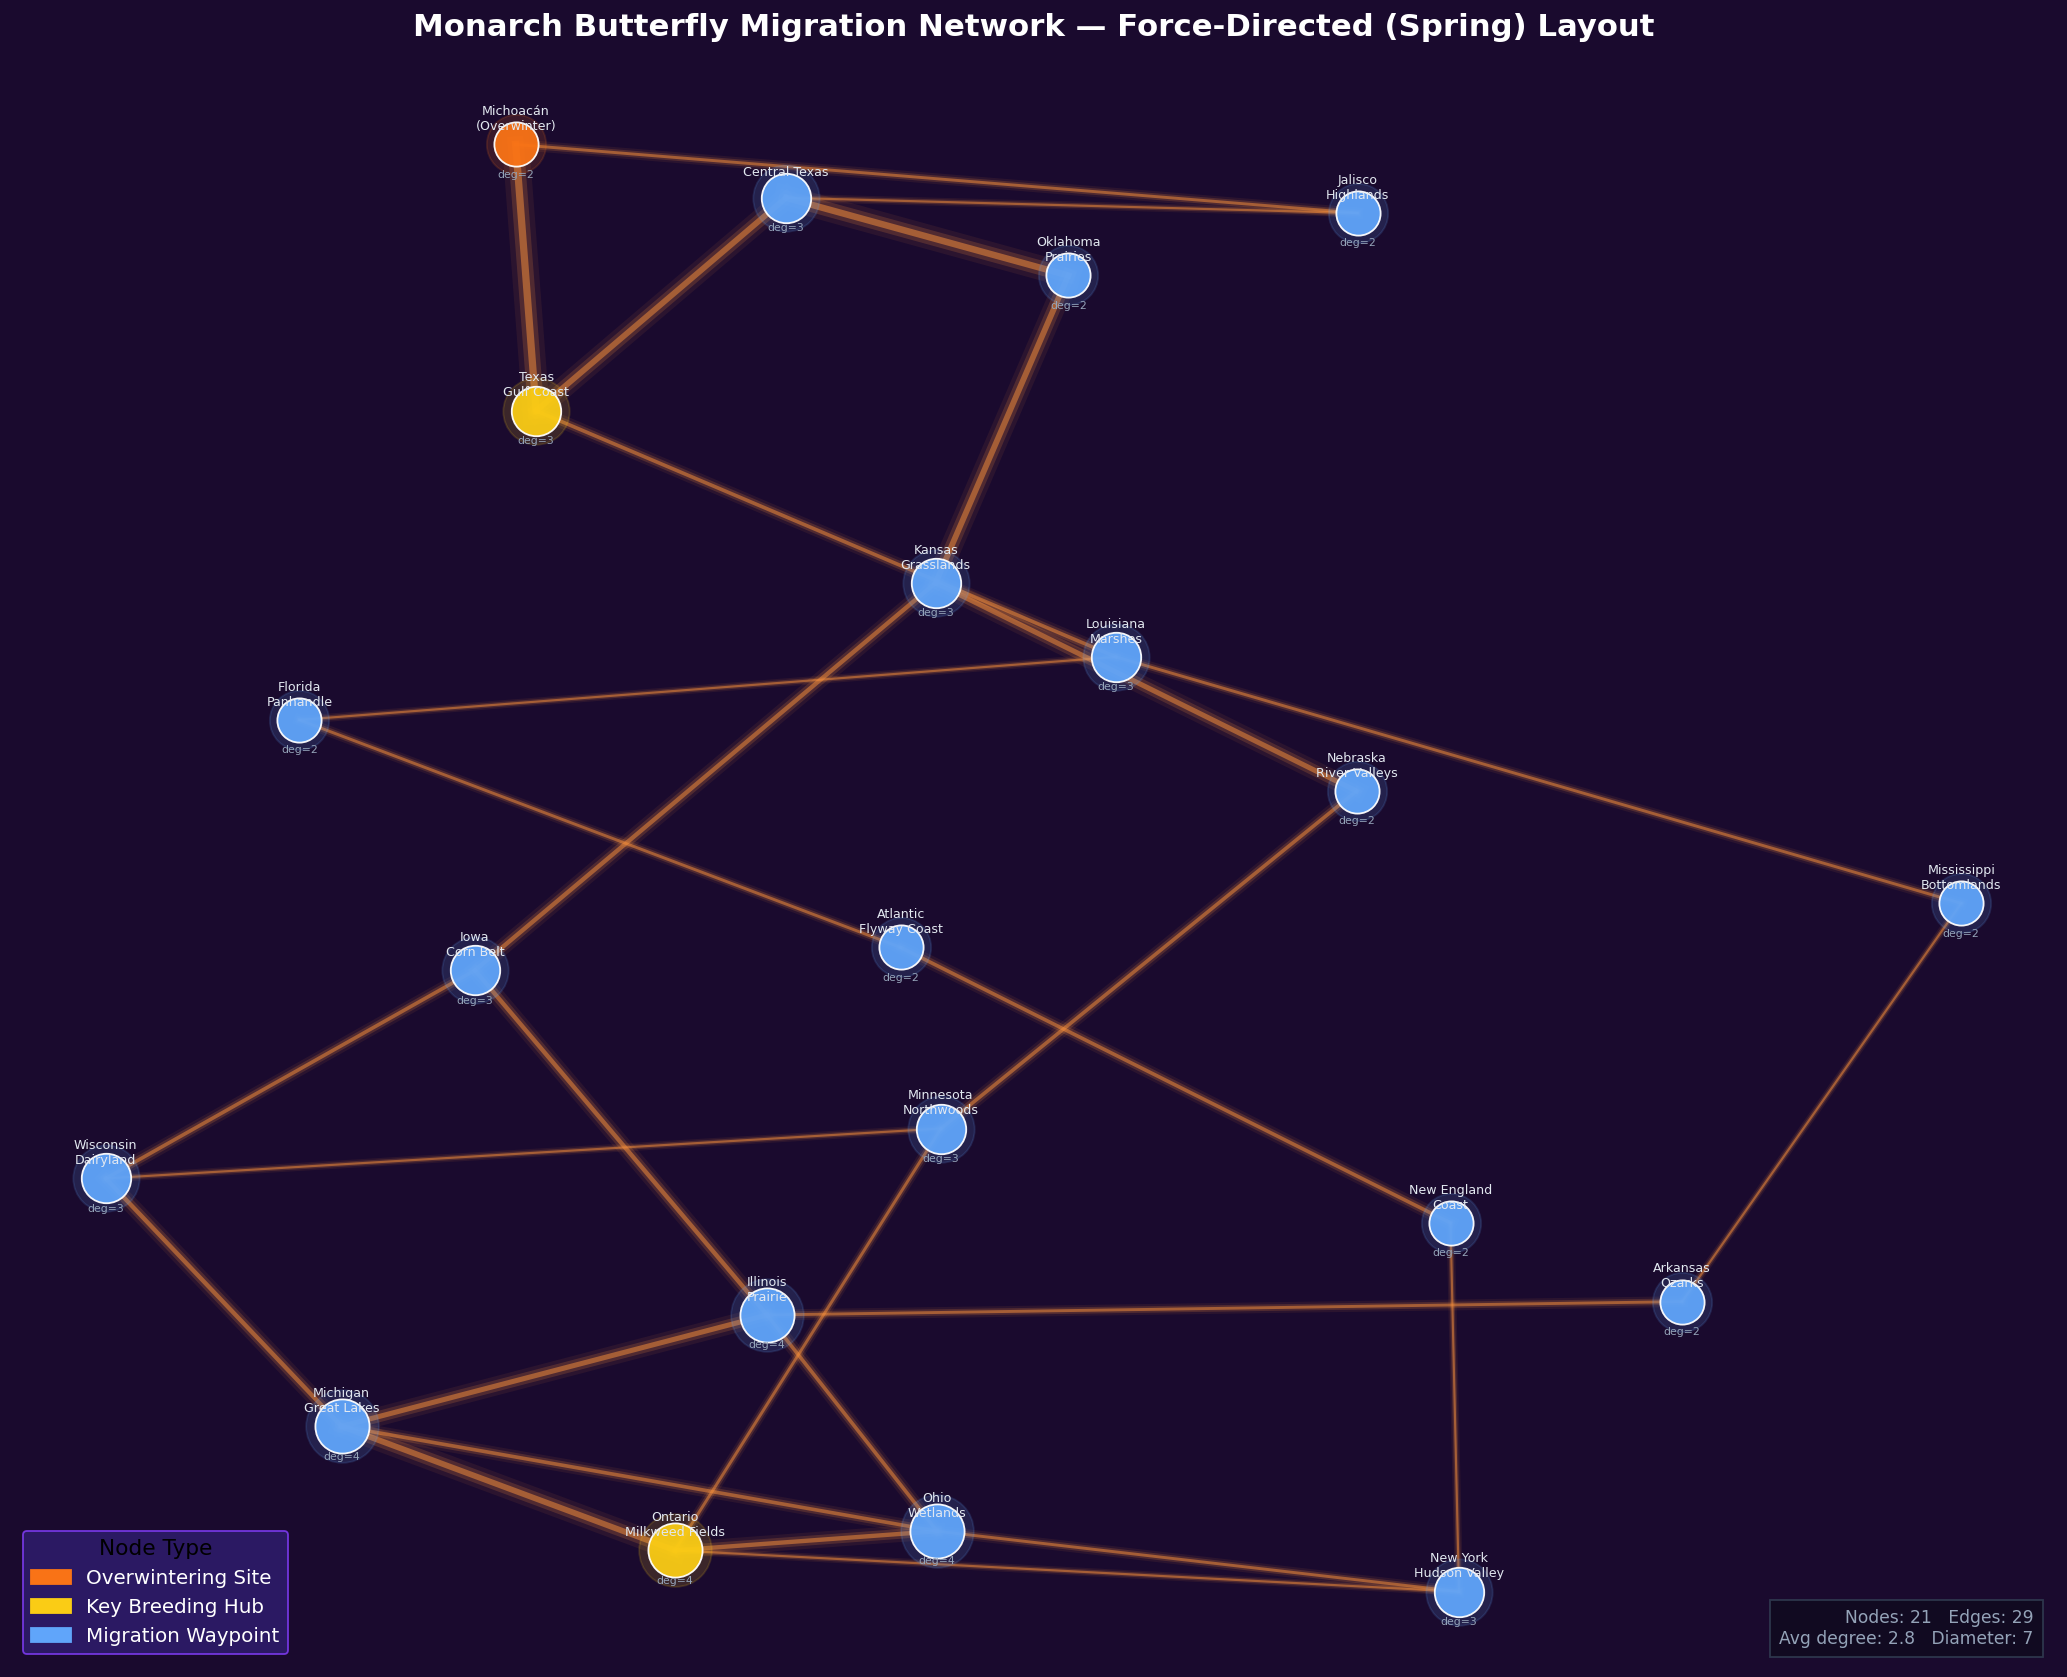

Saved: graph_spring.png


In [8]:
# ── Force-directed layout ────────────────────────────────────────────────────
np.random.seed(42)
pos_spring = nx.spring_layout(G, weight='weight', k=2.5, iterations=120, seed=42)

fig, ax = plt.subplots(figsize=(16, 13), facecolor='#1a0a2e')
ax.set_facecolor('#1a0a2e')
ax.axis('off')

# Draw glowing edges
for u, v in G.edges():
    w = G[u][v]['weight']
    x = [pos_spring[u][0], pos_spring[v][0]]
    y = [pos_spring[u][1], pos_spring[v][1]]
    # Glow effect: draw same edge multiple times with decreasing alpha
    for lw, al in [(w * 1.5, 0.08), (w * 0.9, 0.18), (w * 0.4, 0.5)]:
        ax.plot(x, y, color='#fb923c', linewidth=lw, alpha=al)

# Degree-based node sizing
degrees = dict(G.degree())
max_deg = max(degrees.values())

for n, (x, y) in pos_spring.items():
    col = type_colors[node_type[n]]
    size = 300 + 150 * degrees[n]
    # Halo
    ax.scatter(x, y, s=size * 1.8, c=col, alpha=0.15, zorder=2)
    ax.scatter(x, y, s=size, c=col, zorder=3, edgecolors='white', linewidths=1.0, alpha=0.95)

# Labels
for n, (x, y) in pos_spring.items():
    fontsize = 8.5 if degrees[n] >= 5 else 7
    ax.annotate(n, (x, y), fontsize=fontsize, color='#e2e8f0', ha='center', va='center',
                fontfamily='DejaVu Sans', fontweight='bold' if degrees[n] >= 5 else 'normal',
                xytext=(0, 14), textcoords='offset points')

# Degree as annotation
for n, (x, y) in pos_spring.items():
    ax.annotate(f'deg={degrees[n]}', (x, y), fontsize=6, color='#94a3b8',
                ha='center', va='top', xytext=(0, -14), textcoords='offset points')

# Legend
legend_handles = [mpatches.Patch(color=c, label=t) for t, c in type_colors.items()]
ax.legend(handles=legend_handles, loc='lower left', fontsize=11,
          facecolor='#2d1b69', edgecolor='#7c3aed', labelcolor='white',
          framealpha=0.9, title='Node Type', title_fontsize=12)

# Stats box
stats_text = (f'Nodes: {G.number_of_nodes()}   Edges: {G.number_of_edges()}\n'
              f'Avg degree: {np.mean(list(degrees.values())):.1f}   '
              f'Diameter: {nx.diameter(G)}')
ax.text(0.99, 0.01, stats_text, transform=ax.transAxes,
        fontsize=9.5, color='#94a3b8', ha='right', va='bottom',
        bbox=dict(facecolor='#0f0a1e', edgecolor='#334155', alpha=0.8, pad=5))

ax.set_title('Monarch Butterfly Migration Network — Force-Directed (Spring) Layout',
             fontsize=17, color='white', pad=20, fontweight='bold')

plt.tight_layout()
plt.savefig('graph_spring.png', dpi=150, bbox_inches='tight', facecolor='#1a0a2e')
plt.show()
print('Saved: graph_spring.png')

---
## Summary

| | Dataset | Nodes | Edges | Layouts Used |
|---|---|---|---|---|
| **Tree** | Evolutionary Tree of Life | 68 | 67 | Radial (Dendrogram), Hierarchical (Top-Down) |
| **Graph** | Monarch Butterfly Migration | 21 | 31 | Geographic (Lat/Lon), Force-Directed (Spring) |

**Key observations:**
- The **radial layout** of the phylogenetic tree gives a "sun-burst" view, emphasizing the tree's symmetry and domain diversity.
- The **hierarchical layout** clearly shows evolutionary depth and branching — Eukaryota has far more descendants than Archaea.
- The **geographic layout** of the migration network shows the actual physical flyways used — the central flyway (Texas → Great Plains → Great Lakes) carries the heaviest traffic.
- The **force-directed layout** clusters by connectivity — Michoacán (overwintering site), Michigan, and Ontario emerge as central hubs due to their high weighted degree.
